In [22]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

data = pd.read_csv("data/ethnic female.csv", sep=";")
print(data.head())
print(f"\nВсего записей: {len(data)}")
print(data['национальность'].value_counts())

  национальность   рост масса ширина плеч ширина таза
0            рус  151,5  52,4          37          28
1            рус    171    48          34          27
2            рус    159  76,6          39          39
3            рус    169    70          38        31,5
4            рус    172    61        37,5        30,5

Всего записей: 740
национальность
рус    352
хак    344
тув     44
Name: count, dtype: int64


In [14]:
required_columns = ["рост", "масса", "ширина плеч", "ширина таза"]

for col in required_columns:
    data[col] = data[col].astype(str).str.replace(",", ".", regex=False)


for col in required_columns:
    data[col] = data[col].astype(float)

In [15]:
russian = data[data['национальность'] == 'рус'].head(300)
khakass = data[data['национальность'] == 'хак'].head(300)

df_balanced = pd.concat([russian, khakass], ignore_index=True)
print(f"Русских: {len(russian)}, Хакасок: {len(khakass)}")
print(f"Всего: {len(df_balanced)}")

Русских: 300, Хакасок: 300
Всего: 600


In [ ]:
# Разделение на обучающую и контрольную (70%/30%)
X = df_balanced[['рост', 'масса', 'ширина плеч', 'ширина таза']]
y = df_balanced['национальность']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Обучающая: {len(X_train)}")
print(f"Контрольная: {len(X_test)}")
print(f"\nКлассы в обучении:\n{y_train.value_counts()}")

Обучающая: 420
Контрольная: 180

Классы в обучении:
национальность
рус    210
хак    210
Name: count, dtype: int64


In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=5,
    oob_score=True,
    random_state=42
)

rf.fit(X_train, y_train)
print(f"Random Forest обучен. Деревьев: {rf.n_estimators}")
print(f"OOB точность: {rf.oob_score_:.4f}")
print(f"OOB ошибка: {1 - rf.oob_score_:.4f}")

Random Forest обучен. Деревьев: 100
OOB точность: 0.6738
OOB ошибка: 0.3262


c:\Users\vadin\Projects\AML\venv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\vadin\Projects\AML\venv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\vadin\Projects\AML\venv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\vadin\Projects\AML\venv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\Users\vadin\Projects\AML\venv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some in

Минимальная OOB ошибка: 0.3048 на 30 деревьях


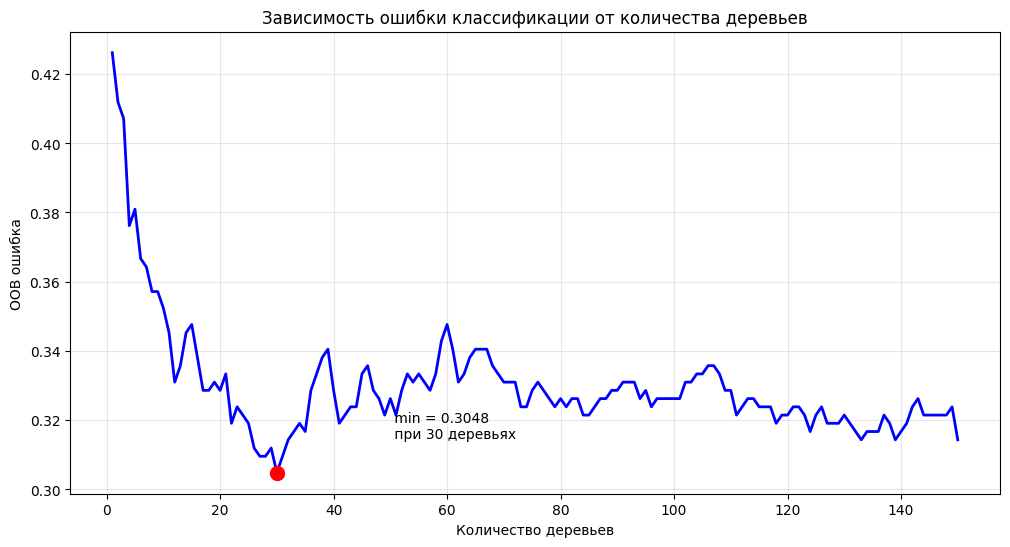

In [ ]:
n_trees = range(1, 151)
oob_errors = []

for n in n_trees:
    rf_temp = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42, min_samples_leaf=5)
    rf_temp.fit(X_train, y_train)
    oob_errors.append(1 - rf_temp.oob_score_)

plt.figure(figsize=(12, 6))
plt.plot(n_trees, oob_errors, 'b-', linewidth=2)
plt.xlabel('Количество деревьев')
plt.ylabel('OOB ошибка')
plt.title('Зависимость ошибки классификации от количества деревьев')
plt.grid(True, alpha=0.3)

min_error = min(oob_errors)
best_n = n_trees[oob_errors.index(min_error)]
plt.plot(best_n, min_error, 'ro', markersize=10)
plt.annotate(f' min = {min_error:.4f}\n при {best_n} деревьях', 
             xy=(best_n, min_error), xytext=(best_n + 20, min_error + 0.01))

print(f"Минимальная OOB ошибка: {min_error:.4f} на {best_n} деревьях")

Информативность признаков:
  рост: 0.4387
  масса: 0.2363
  ширина плеч: 0.1544
  ширина таза: 0.1707


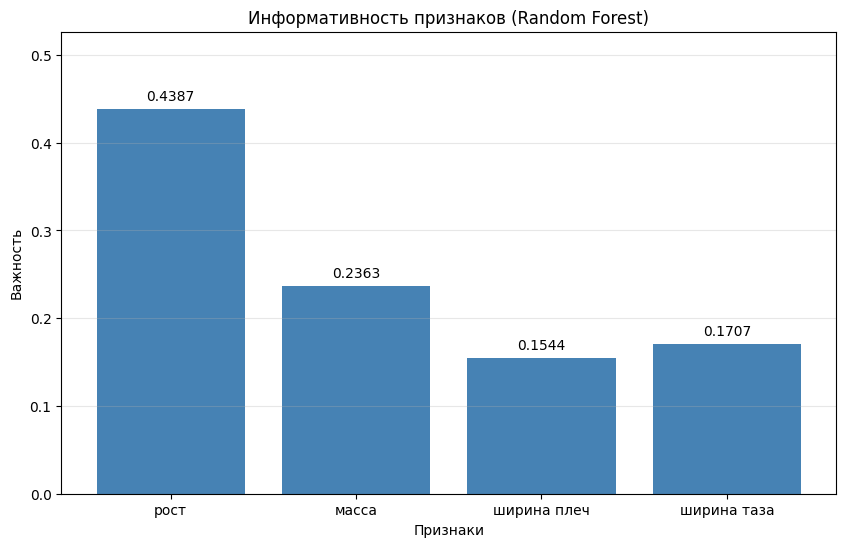

In [ ]:
# Гистограмма информативности признаков
feature_names = ['рост', 'масса', 'ширина плеч', 'ширина таза']
importances = rf.feature_importances_

plt.figure(figsize=(10, 6))
plt.bar(feature_names, importances, color='steelblue')
plt.xlabel('Признаки')
plt.ylabel('Важность')
plt.title('Информативность признаков (Random Forest)')
plt.ylim(0, max(importances) * 1.2)
plt.grid(True, alpha=0.3, axis='y')

for i, (name, imp) in enumerate(zip(feature_names, importances)):
    plt.text(i, imp + 0.01, f'{imp:.4f}', ha='center')

print("Информативность признаков:")
for name, imp in zip(feature_names, importances):
    print(f"  {name}: {imp:.4f}")

In [30]:
# Ячейка 7: Задание 4 - Классификация контрольной выборки
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
cm = confusion_matrix(y_test, y_pred)

print("=== Классификация контрольной выборки ===")
print(f"Точность: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Ошибка: {error_rate:.4f} ({error_rate*100:.2f}%)")
print("\nМатрица ошибок:")
print(cm)
print("\nОтчет по классам:")
print(classification_report(y_test, y_pred))

=== Классификация контрольной выборки ===
Точность: 0.6556 (65.56%)
Ошибка: 0.3444 (34.44%)

Матрица ошибок:
[[62 28]
 [34 56]]

Отчет по классам:
              precision    recall  f1-score   support

         рус       0.65      0.69      0.67        90
         хак       0.67      0.62      0.64        90

    accuracy                           0.66       180
   macro avg       0.66      0.66      0.66       180
weighted avg       0.66      0.66      0.66       180



In [ ]:
nb_gaussian = GaussianNB()
nb_gaussian.fit(X_train, y_train)
y_pred_nb = nb_gaussian.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred_nb)
error_nb = 1 - accuracy_nb

print("\n=== СРАВНЕНИЕ МЕТОДОВ ===")
print(f"Random Forest (bagging):")
print(f"  Точность: {accuracy:.4f}, Ошибка: {error_rate:.4f}")
print(f"Naive Bayes (Gaussian):")
print(f"  Точность: {accuracy_nb:.4f}, Ошибка: {error_nb:.4f}")


=== СРАВНЕНИЕ МЕТОДОВ ===
Random Forest (bagging):
  Точность: 0.6556, Ошибка: 0.3444
Naive Bayes (Gaussian):
  Точность: 0.7111, Ошибка: 0.2889
